Dyngen batch effect

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

# 使用rcParams全局设置隐藏所有边框
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.bottom'] = False
mpl.rcParams['axes.spines.left'] = False

# 可选：如果你也想隐藏刻度线和刻度标签
mpl.rcParams['xtick.bottom'] = False
mpl.rcParams['xtick.labelbottom'] = False
mpl.rcParams['ytick.left'] = False
mpl.rcParams['ytick.labelleft'] = False

In [2]:
data_dir = 'dyngen'
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'
save_dir = f'../figures/dyngen/batch'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
cluster_key = 'progress'
batch_key = 'model'
basis = 'umap'

In [4]:
batch_list = ['batch-left', 'batch-right']
model_list = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
model_name_list = ['scvelo_dynamical', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']

In [5]:
import anndata as ad
adata_dict = {}
for model in model_list:
    adata_dict[model] = []
for batch in batch_list:
    for model, model_name in zip(model_list, model_name_list):
        adata_path = f'{base_dir}/{data_dir}/{batch}/{model}/{model_name}.h5ad'
        vkey = f'{model_name}_velocity'
        adata = sc.read_h5ad(adata_path)
        adata_velo = ad.AnnData(X=adata.layers[vkey])
        adata_velo.obs_names = adata.obs_names
        adata_velo.var_names = adata.var_names
        adata_dict[model].append(adata_velo)
adata_concat_dict = {}
for model in model_list:
    adata_concat = ad.concat(adata_dict[model])
    adata_concat_dict[model] = adata_concat
adata_concat_dict

{'scvelo': AnnData object with n_obs × n_vars = 4000 × 535,
 'unitvelo': AnnData object with n_obs × n_vars = 4000 × 535,
 'velovae': AnnData object with n_obs × n_vars = 4000 × 535,
 'deepvelo_cui': AnnData object with n_obs × n_vars = 4000 × 535,
 'latentvelo': AnnData object with n_obs × n_vars = 4000 × 535,
 'velovi': AnnData object with n_obs × n_vars = 4000 × 190,
 'stt': AnnData object with n_obs × n_vars = 4000 × 535,
 'velovgi': AnnData object with n_obs × n_vars = 4000 × 535}

In [6]:
data_ref_dir = 'dyngen/batch-dataset_modified'
model_ref_list = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
data_ref_dict = {}
for model, model_ref_dir, model_name in zip(model_list, model_ref_list, model_name_list):
    adata_path = f'{base_dir}/{data_ref_dir}/{model_ref_dir}/{model_name}.h5ad'
    adata = sc.read_h5ad(adata_path)
    adata_batch = adata_concat_dict[model]
    common_genes = list(set(adata.var_names) & set(adata_batch.var_names))
    adata_batch_aligned = adata_batch[:, common_genes].copy()
    adata_aligned = adata[adata_batch_aligned.obs_names, adata_batch_aligned.var_names].copy()
    adata_aligned.layers['batch_velo'] = adata_batch_aligned.X
    data_ref_dict[model] = adata_aligned
data_ref_dict

{'scvelo': AnnData object with n_obs × n_vars = 4000 × 535
     obs: 'step_ix', 'simulation_i', 'sim_time', 'model', 'progress', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'pred_t'
     var: 'module_id', 'basal', 'burn', 'independence', 'color', 'is_tf', 'is_hk', 'transcription_rate', 'splicing_rate', 'translation_rate', 'mrna_halflife', 'protein_halflife', 'mrna_decay_rate', 'protein_decay_rate', 'max_premrna', 'max_mrna', 'max_protein', 'mol_premrna', 'mol_mrna', 'mol_protein', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
     uns: 'log1p', 'model_colors', 'neighbors', 'pca', 'progress_colors', 'recover_dynamics', 'traj_dimred_segments', 'traj_milestone_networ

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

scvelo 191
unitvelo 522
velovae 535
deepvelo_cui 535
latentvelo 535
velovi 187
stt 535
velovgi 535


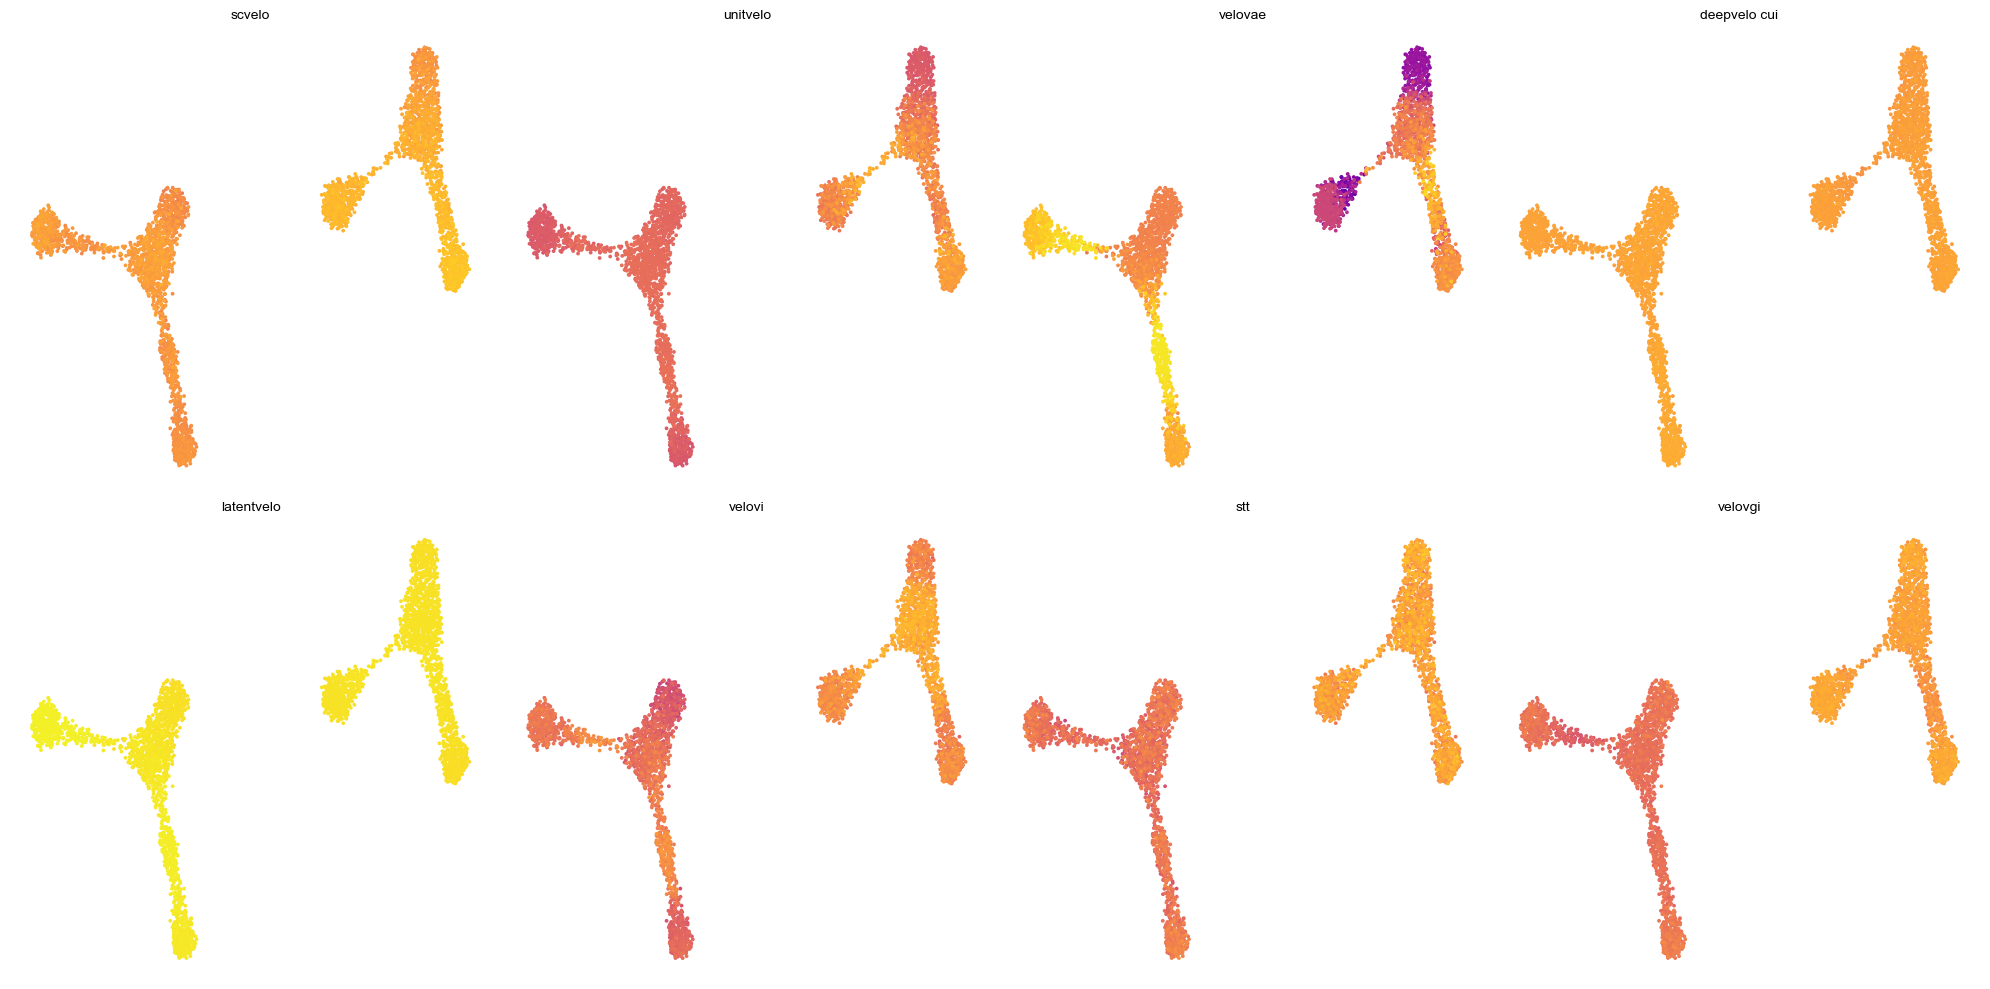

In [8]:
n_rows = 2
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))

for i, (model, adata) in enumerate(data_ref_dict.items()):
    vkey = f'{model_name_list[i]}_velocity'
    non_nan_cols = ~np.isnan(adata.layers['batch_velo']).any(axis=0) & ~np.isnan(adata.layers[vkey]).any(axis=0)
    adata = adata[:, non_nan_cols].copy()
    print(model, adata.n_vars)
    adata.obs['batch_sim'] = cosine_similarity(adata.layers['batch_velo'], adata.layers[vkey]).diagonal()
    scv.pl.scatter(adata, basis=basis, color='batch_sim', title=model, color_map='plasma', vmin=-1, vmax=1, ax=axes[i // n_cols, i % n_cols], show=False, colorbar=False)
plt.tight_layout()
plt.savefig(f'{save_dir}/batch_velocity_correlation.svg', bbox_inches='tight')
plt.show()